# MNIST Datastructuren & Visualisatie-opdracht

## Doelstelling
Begrijpen hoe je hoog-dimensionale data kunt representeren en visualiseren met behulp van verschillende **NumPy-gegevensstructuren** en **matplotlib-visualisatietechnieken**.

Laad de mnist data uit **tensorflow.keras.datasets**. 

# MNIST Datastructuren & Visualisatie-opdracht

## Doelstelling
Begrijpen hoe je hoog-dimensionale data kunt representeren en visualiseren met behulp van verschillende **NumPy-gegevensstructuren** en **matplotlib-visualisatietechnieken**.

Laad de mnist data uit **tensorflow.keras.datasets**. 

_Oplossing_

## Taak 3: Verschillende datastructuren onderzoek

Laad de mnist database in verschillende datastructuren
- lijst
- queue
- dictionary

Wat zijn typische acties die je zou willen doen met deze database? 

Als voorbeeld probeer het voor de volgende gevallen met deze verschillende datastructuren:
- Zoek eerste afbeelding van label 5
- voeg een nieuw element toe
- Loop door de gehele db
- optioneel: bedenk zelf iets



Hoe kun je het goed opmeten (eg in bovenstaande voorbeeld krijg je nu mogelijk overal 0.0s omdat het allemaal snel gaat)

Kies een lastige feature

_Voorbeeld:_

Zoek de eerste afbeelding van een even nummer groter dan 5

Of zoek alle afbeeldingen waar de som van pixelwaarden > 10000

Of zoek alle afbeeldingen met een specifieke combinatie van labels en pixelkenmerken

Daardoor wordt het verschil tussen lijsten, queues en dictionaries veel zichtbaarder.

_Oplossing_

In [49]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

print("Loading set")
# Load MNIST dataset
(train_images, train_labels), (x_test, y_test) = mnist.load_data()
print("Loaded")


Loading set
Loaded


In [50]:
# naive, using for loop
# mlist = list()
# for _, i in enumerate(train_images):
#     mlist.append((train_images[i], train_labels[i]))

# using zip
mlist = list(zip(train_images, train_labels))

both methods of creating a single list with tuples are incredibly slow. For preformances sake it is better to use two lists if this is truely needed.

In [51]:
class queue:
    def __init__(self, iter = None):
        if iter is None:
            self._backing_list = deque()
            return
        self._backing_list = deque(iter)

    def enqueue(self, value):
        self._backing_list.insert(0, value)

    def dequeue(self):
        return self._backing_list.pop()

    def peek(self):
        return self._backing_list[-1]

    def __len__(self):
        return len(self._backing_list)

    def __next__(self):
        return self._backing_list.__next__()

In [52]:
mlist = list(zip(train_labels, train_images))
mqueue = queue(mlist)
mdict = {}
for kvp in mlist:
    k = kvp[0].item()
    if k not in mdict.keys():
          mdict[k] = []
    mdict[k].append([kvp[1]])

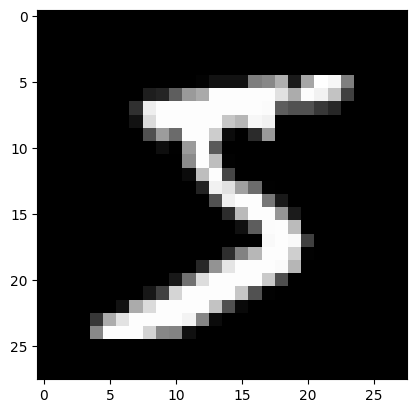

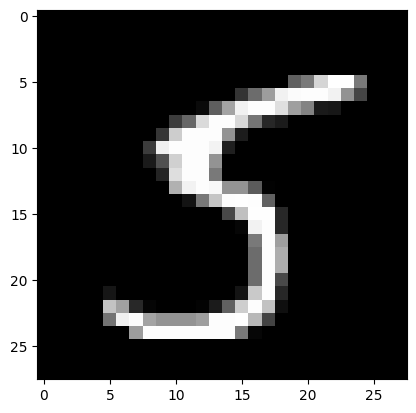

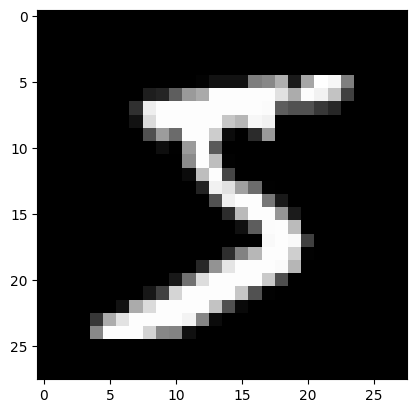

In [53]:
for kvp in mlist:
    if kvp[0] == 5:
            plt.imshow(kvp[1], cmap="gray")
            plt.show()
            break

while True:
    kvp = mqueue.dequeue()
    if kvp[0] == 5:
            plt.imshow(kvp[1], cmap="gray")
            plt.show()
            break

plt.imshow(mdict[5][0][0], cmap="gray")
plt.show()

In [54]:
for kvp in mlist:
    continue

while len(mqueue) > 0:
    mqueue.dequeue()

for nums in mdict.keys():
    for val in mdict[nums]:
        continue

In [55]:
num_to_add = (train_images[500], train_labels[500])
mlist.append(num_to_add)

mqueue.enqueue(num_to_add)

mdict[train_labels[500]].append(train_images[500])

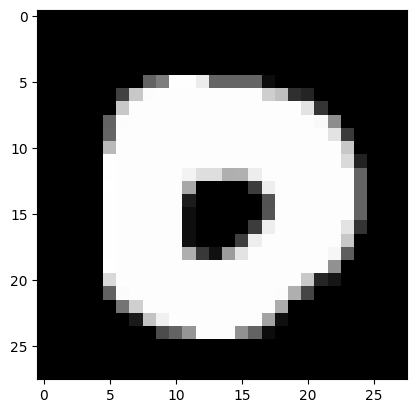

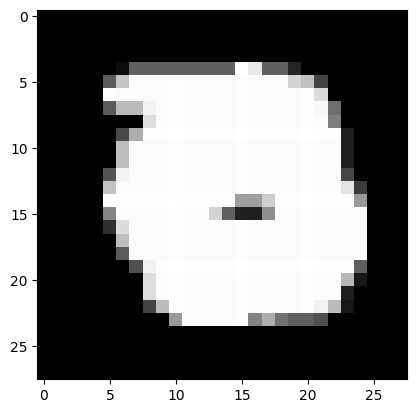

In [56]:
first_larger = 0
for k in mdict.keys():
    if k % 2 == 0 and k > 5:
        first_larger = k
        break

large_images = list()
for kvp in mlist:
    if kvp[1].sum() > 70000:
        large_images.append(kvp[1])

for image in large_images:
    plt.imshow(image, cmap="gray")
    plt.show()
